# Week 3 Notebook 2: The first ten minutes with any dataset

**CSC: Data Analytics, Data Mining and Machine Learning**

Every dataset you meet gets the same opening routine. Before modelling or answering a research question, first learn what you actually have.

### Today’s routine
**Size -> rows -> column types -> missing values -> duplicates -> numerical summaries -> distributions -> relationships**

The examples use the Palmer Penguins dataset because it is small, real, and contains common data-quality issues.

## Setup

In [4]:
# pandas: tables and data cleaning; numpy: numerical operations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and chart defaults for the rest of the notebook.
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## Load the data

This notebook uses the **Palmer Penguins** dataset: 344 penguins measured at Palmer Station, Antarctica. It is small, real, and messy in all the usual ways.

Your group's data may not be a CSV file. Pandas can read several common table formats. Choose the reader that matches the file you have:

| File type | Pandas reader |
| --- | --- |
| CSV | `pd.read_csv(...)` |
| TSV or other separated text | `pd.read_csv(..., sep="\t")` |
| Excel | `pd.read_excel(...)` |
| JSON | `pd.read_json(...)` |
| Parquet | `pd.read_parquet(...)` |

Run the penguins example first. Then replace `file_path` and uncomment one alternative reader for your own data. Excel and Parquet files may need an additional package installed in your Python environment.

In [ ]:
# Load the file into a pandas DataFrame called df.
file_path = "data/DataSet_AIvsHuman.csv"
df = pd.read_csv(file_path)

# For another file, replace file_path and use the matching reader:
# df = pd.read_csv("../data/your_file.tsv", sep="\t")
# df = pd.read_excel("../data/your_file.xlsx")
# df = pd.read_json("../data/your_file.json")
# df = pd.read_parquet("../data/your_file.parquet")

# Preview the first five rows to check that the file loaded as expected.
df.head()

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
0,1,Write a string manipulation solution in python,def string_manipulation():\n # TODO: implem...,code,blog,human,string manipulation,9,84,NaN,python,3,True
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,text,generated,ai,finance,42,298,Claude,en,10,False
4,5,Provide a graph traversal algorithm in cpp,vector<int> arr; // graph traversal example\nf...,code,generated,ai,graph traversal,11,98,Gemini,cpp,10,True


---
## Move 1: How big is it?

Start with the number of **rows and columns**. If the size surprises you, stop and find out why.

In [8]:
# shape returns (number_of_rows, number_of_columns).
print("rows, columns:", df.shape)

rows, columns: (20000, 13)


## Move 2: What does a row look like?

Look at a few rows. This helps you understand what one observation represents and whether the values look sensible.

In [9]:
# head() shows the first five rows of the table.
df.head()

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
0,1,Write a string manipulation solution in python,def string_manipulation():\n # TODO: implem...,code,blog,human,string manipulation,9,84,NaN,python,3,True
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,text,generated,ai,finance,42,298,Claude,en,10,False
4,5,Provide a graph traversal algorithm in cpp,vector<int> arr; // graph traversal example\nf...,code,generated,ai,graph traversal,11,98,Gemini,cpp,10,True


## Move 3: What type is each column?

The single most common data bug: a number stored as text. Use `.info()` to check the data types and whether columns contain missing values.

In [10]:
# info() shows column names, data types, and non-missing value counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 20000 non-null  int64
 1   prompt             20000 non-null  str  
 2   content            20000 non-null  str  
 3   type               20000 non-null  str  
 4   source             20000 non-null  str  
 5   label              20000 non-null  str  
 6   topic              20000 non-null  str  
 7   word_count         20000 non-null  int64
 8   char_count         20000 non-null  int64
 9   ai_model           10004 non-null  str  
 10  language           20000 non-null  str  
 11  complexity_score   20000 non-null  int64
 12  is_multiline_code  20000 non-null  bool 
dtypes: bool(1), int64(4), str(8)
memory usage: 7.1 MB


## Move 4: What is missing?

Counts tell you how much is missing; percentages make it easier to compare columns of different sizes.

Missing data is not automatically an error. First find out **where it is missing and why** before deciding what to do with it.

In [11]:
# Count missing cells in each column.
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})

# Sort so the columns needing the most attention appear first.
missing.sort_values("n_missing", ascending=False)

,n_missing,pct_missing
ai_model,9996,50.0
prompt,0,0.0
content,0,0.0
type,0,0.0
id,0,0.0
source,0,0.0
label,0,0.0
word_count,0,0.0
topic,0,0.0
char_count,0,0.0


### A question worth asking

Are the missing values scattered through the dataset, or do they occur in particular groups or parts of the file? A pattern in missingness can tell you something about how the data were collected.

---
## Move 5: Duplicates

Exact duplicate rows can indicate a data-processing problem. Check them before analysing the data.

In [12]:
# duplicated() marks rows that are exact copies of an earlier row.
# sum() counts how many duplicate rows were found.
print("exact duplicate rows:", df.duplicated().sum())

exact duplicate rows: 0


---
## Move 6: Summarise the numbers

`.describe()` gives count, mean, standard deviation, minimum, quartiles and maximum for numeric columns.

**Look at the minimum and maximum first.** They can reveal impossible or suspicious values before the average hides them.

In [13]:
# describe() calculates common summaries for numeric columns.
# Transpose so each variable appears as a row, which is easier to read.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,20000.0,10000.50000,5773.647028,1.0,5000.75,10000.5,15000.25,20000.0
word_count,20000.0,28.31710,17.297994,9.0,13.00,25.0,43.00,67.0
char_count,20000.0,206.63515,122.430413,52.0,96.00,176.5,314.00,473.0
complexity_score,20000.0,5.50605,2.880100,1.0,3.00,6.0,8.00,10.0


---
## Move 7: Look at the distributions

Now connect this notebook to the previous one: use histograms to see the shape of every numeric variable.

Look for:
- skew
- multiple peaks
- gaps
- suspicious spikes
- values that look impossible

You do not need to interpret every detail yet. The goal is to notice what deserves a closer look.

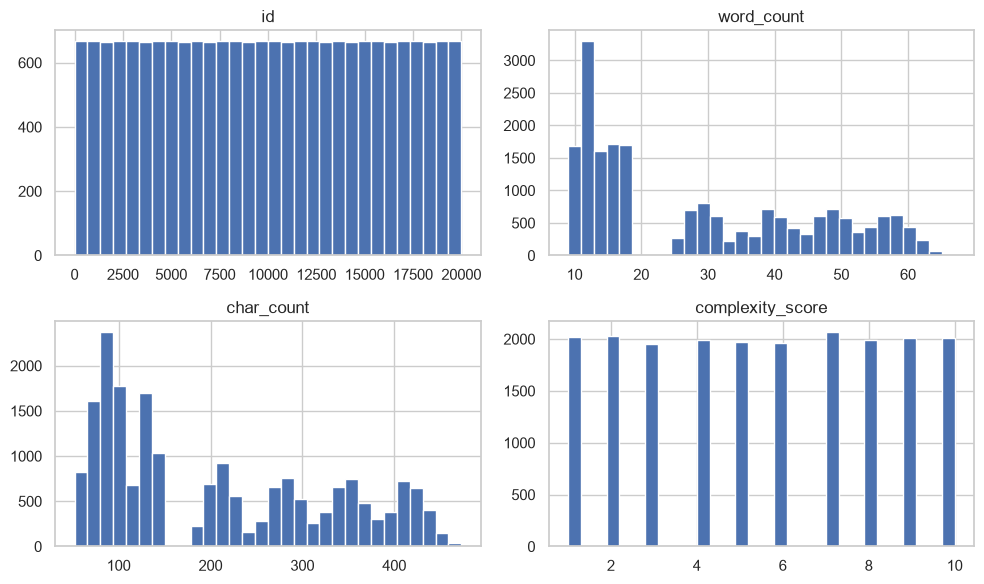

In [14]:
# Select numeric columns and draw one histogram for each.
df.select_dtypes("number").hist(figsize=(10, 6), bins=30, edgecolor="white")
plt.tight_layout()
plt.show()

### One thing to notice

Look at `bill_depth_mm`. It does not look like one simple hump. A distribution can contain multiple groups mixed together, which is one reason that **grouping variables matter**.

---
## Move 8: How do the numbers relate?

A correlation matrix is a fast first pass for numeric variables. In this notebook, pandas uses **Pearson correlation** by default. Pearson correlation measures the strength and direction of a **linear relationship**: whether larger values of one variable tend to occur with larger or smaller values of another variable in a roughly straight-line pattern.

Pearson correlation ranges from `-1` to `1`:

- `1` means a perfect positive linear relationship;
- `-1` means a perfect negative linear relationship; and
- `0` means no linear relationship.

A value near `0` does not prove that there is no relationship. A curved relationship can have a small Pearson correlation. Treat this matrix as a screening tool, then inspect a scatter plot.

Other correlation measures answer slightly different questions. **Spearman correlation** compares the ranks of values and is useful for a consistently increasing or decreasing relationship that is not straight. **Kendall correlation** also uses ranks and is often useful with smaller datasets or many tied values.

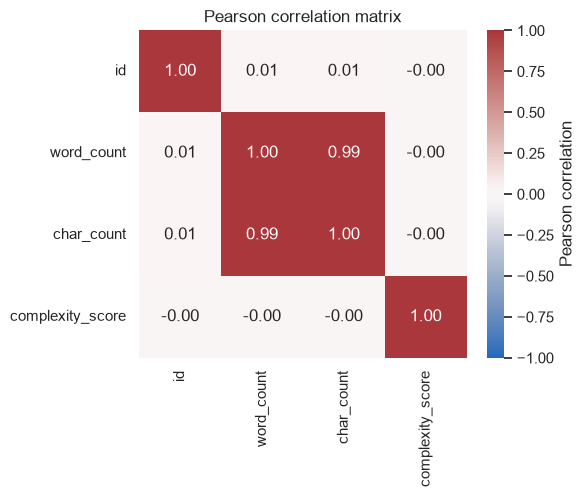

In [15]:
# Select numeric columns and calculate Pearson correlations.
# Pearson is pandas' default method and measures linear relationships.
numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

# A heatmap makes positive and negative relationships easier to scan.
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

## The routine to remember

Use this order when you receive a new dataset:

**How big is it? -> What is one row? -> What are the columns? -> What is missing? -> Are there duplicates? -> What do the numbers look like? -> What relationships are visible?**

Only after this first look should you start making stronger decisions about cleaning, modelling, or statistical analysis.